

<p><img height="80px" src="https://www.upm.es/sfs/Rectorado/Gabinete%20del%20Rector/Logos/UPM/Escudo/EscUpm.jpg" align="left" hspace="0px" vspace="0px"></p>

**Course "Artificial Neural Networks and Deep Learning" - Universidad Politécnica de Madrid (UPM)**

# **Deep Q-Learning for Lunar Lander**

Group members: Juan García Santos, Guillermo Alonso Rello, Janire Amesti Soler, Daniel Henríquez Quesada
Group members emails: {juan.gsantos, guillermo.alonsor, janire.amesti, daniel.henriquez.quesada}@alumnos.upm.es


# Lunar lander environment


Documentation: https://gymnasium.farama.org/environments/box2d/lunar_lander/

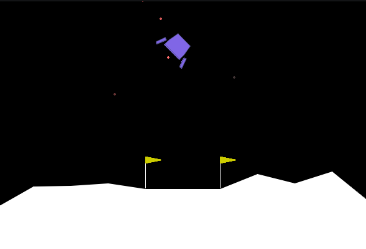

This environment is part of the Box2D environments which contains general information about the environment.



## Description
This environment is a classic rocket trajectory optimization problem. According to Pontryagin’s maximum principle, it is optimal to fire the engine at full throttle or turn it off. This is the reason why this environment has discrete actions: engine on or off.

There are two environment versions: discrete or continuous, the discrete one will be used because of DQN algorithm. The landing pad is always at coordinates (0,0). Landing outside of the landing pad is possible. Fuel is infinite, so an agent can learn to fly and then land on its first attempt.

## Discrete action Space
There are 4 discrete actions available:

- 0: do nothing

- 1: fire left orientation engine

- 2: fire main engine

- 3: fire right orientation engine

## Observation Space
The state is an 8-dimensional vector of floats:

- (x,y) Coordinates of the lander
- (vx,vy) linear velocities
- Angle
- Angular velocity
- Two booleans that represent whether each leg is in contact with the ground or not.

The units of the state are not consistent, we can't say that e.g. the angular velocity is rad/sec (in the documentation they provide the scale factors to make it rad/sec).

## Rewards
After every step a reward is granted. The total reward of an episode is the sum of the rewards for all the steps within that episode.

For each step, the reward:

- Is increased/decreased the closer/further the lander is to the landing pad -> encourage getting closer to the landing pad (unique reward for that).

- Is increased/decreased the slower/faster the lander is moving -> encourage moving slowly (better control).

- Is decreased the more the lander is tilted (angle not horizontal) -> encourage upstanding angle stability.

- Is increased by 10 points for each leg that is in contact with the ground -> encourage reaching the ground.

- Is decreased by 0.03/0.3 points each frame a side engine/main engine is firing -> encourage low use of engines (better to descend without them).

The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively (it doesn't matter if it is in the landing pad or not).

An episode is considered a successful solution if it scores at least 200 points.

## Starting State
The lander starts at the top center of the viewport with a random initial force applied to its center of mass -> the controller must learn the extra challenge of stabilizing given the initial perturbation.

## Episode Termination
The episode finishes if:

- The lander crashes (the lander body gets in contact with the moon) -> -100 of reward.

- The lander gets outside of the viewport (x coordinate is greater than 1).

- The lander is not awake. From the Box2D docs, a body which is not awake is a body which doesn’t move and doesn’t collide with any other body.

- Episode maximum lenght is 1000, it will get truncated there.

## Arguments

import gymnasium as gym
env = gym.make(
    "LunarLander-v2",
    continuous: bool
    gravity: float
    enable_wind: bool
    wind_power: float
    turbulence_power
)

- Gravity: is the gravitational constant, (bounded to be within 0 and -12).

- Wind: generated using the function tanh(sin(2 k (t+C)) + sin(pi k (t+C))). k is set to 0.01. C is sampled randomly between -9999 and 9999.

- Wind power: maximum magnitude of linear wind applied to the craft. The recommended value is between 0.0 and 20.0.

- Turbulence power: maximum magnitude of rotational wind applied to the craft. The recommended value is between 0.0 and 2.0.

# Changes and Experiments
- REPLAY MEMORY adjustments: the base implementation does not account for exceeding its maximum size, which would result in an error, so the code must be modified for long trainings. It has been found that the ideal is to use a large memory size and have a FIFO type circular queue mechanism in case the size is exceeded during training. This involves replacing the oldest elements with new elements to be added. The distribution of rewards from transitions has been analyzed and tested for storing fewer values close to zero in memory, as they are very abundant, but this has not worked well, so we keep all.

- Target network to stabilize the training process. This implies the existence of a hyperparameter of how many steps to match both networks. In this discussion, it is suggested that it be 2 orders of magnitude greater than the times you execute the train on batch. https://ai.stackexchange.com/questions/21984/in-deep-q-learning-are-the-target-update-frequency-and-the-batch-_oning-frequ
After tests with values of 100 and 200 in this hyperparameter, it has been concluded that 100 works better.

- Tests have been conducted in Colab, Kaggle, and locally, and in the 3 options the existence of a memory leak meant that we could not manage to train the entire network without running out of memory. After investigating, it has been found that the use of the function keras.backend.clear_session() fixes it (cleans the neural network graph) and is called every certain number of iterations, since it is inefficient to do so. https://stackoverflow.com/questions/76282813/memory-leak-after-calling-keras-model-fit

- The exploration decay has been divided by 10 compared to the cartpole problem, since in this scenario the episodes last about 10 times longer than in the cartpole (approximately between 100 and 1000) to explore above the established minimum value (0.01) for a sufficient number of episodes (approximately during the first 35).

- To finish the training in the shortest time and during a stable phase, a stopping condition has been added that consists of if the last 10 episodes have been successful (with scores of 200 or more), it is considered to have stabilized and can be stopped without reaching the established maximum iterations.

- Various network structures have been tested, and using 3 layers has been the best (layers of 256, 128 and 64 neurons). Networks of 1 and 2 layers do not learn and neither do 4 layers. Using a batch size larger than 32 makes it not learn. Trained with Adam.

- Generation of videos through a callback. During the test phase, videos of each episode are generated and saved in a folder. In this document appear the most significant: cases of success and failure.

## Summary of the best configuration:
- A large REPLAY MEMORY (100K) with a FIFO circular queue mechanism.
- A target network update frequency hyperparameter set to 100 steps.
- An exploration decay rate divided by 10 from the one used for the cartpole problem (0.995 -> 0.9995)
- An early stopping condition based on the success of the last 10 episodes (scores of 200 or more).
- A neural network structure with three layers.
- A batch size of 32.
- The rest of the hyperparameters are the same than in the cartpole problem.
- A callback for generating videos during the test phase.

## Computer specs:
Although we have done tests in colab, locally, and kaggle, most of the tests have been on the latter. 29 GB of RAM and Nvidia P100 GPU with 16GB.

In [2]:
# Reference for imports: https://github.com/hom-bahrani/Gymnasium-Colaboratory-Starter/blob/main/gymnasium_colab_starter.ipynb

!apt-get update -y > /dev/null 2>&1

!apt-get install xvfb -y

!pip install swig > /dev/null 2>&1
!pip install gymnasium[all] > /dev/null 2>&1
!pip install pyvirtualdisplay > /dev/null 2>&1
!pip install -U colabgymrender

!pip install Box2D
!pip install box2d-kengz

!pip install natsort

!apt-get install x11-utils > /dev/null 2>&1
!pip install pyglet > /dev/null 2>&1

!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!apt-get install cmake > /dev/null 2>&1

!pip install psutil

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libfontenc1 libxfont2 libxkbfile1 x11-xkb-utils xfonts-base xfonts-encodings xfonts-utils
  xserver-common
The following NEW packages will be installed:
  libfontenc1 libxfont2 libxkbfile1 x11-xkb-utils xfonts-base xfonts-encodings xfonts-utils
  xserver-common xvfb
0 upgraded, 9 newly installed, 0 to remove and 29 not upgraded.
Need to get 7,816 kB of archives.
After this operation, 11.9 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libfontenc1 amd64 1:1.1.4-1build3 [14.7 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libxfont2 amd64 1:2.0.5-1build1 [94.5 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 libxkbfile1 amd64 1:1.1.0-1build3 [71.8 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/main amd64 x11-xkb-utils amd64 7.7+5build4 [172 kB]
Get:5 http://archiv

In [13]:
import gymnasium as gym
from gymnasium import logger as gymlogger
from gymnasium.wrappers.record_video import RecordVideo
#gymlogger.set_level(40) #error only

import numpy as np
from tensorflow import keras
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import time
import random
import math
import uuid
import glob
import io
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay
import gc # Garbage collector
import psutil

## Hyperparameters

In [8]:
GAMMA = 0.99 # Bellman eq
MEMORY_SIZE = 100000 # Size of the replay memory
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EXPLORATION_MAX = 1
EXPLORATION_MIN = 0.01
EXPLORATION_DECAY = 0.9995 # Decay applied in each step to the exploration rate
NUMBER_OF_EPISODES_FOR_TRAINING = 400 # Max iters, it will stop before because of the stopping condition.
NUMBER_OF_EPISODES_FOR_TESTING = 60
USE_TARGET_NET = True
TARGET_UPDATE_FREQ = 100 # How many steps to wait until doing target_model = model
SUCCESS_SCORE = 200 # The doc of the library states that this is the min score to success in the landing
STOPPING_STABLE_ITERS = 10 # Num of iterations that the model has to score on avg more than SUCCESS_SCORE

RECORDING_FREQUENCY = 1 # Frequency of video recording (each x episodes)
ENVIRONMENT_NAME = "LunarLander-v2"

## Class ReplayMemory

Memory of transitions for experience replay.

In [9]:
import random
class ReplayMemory:

    def __init__(self,number_of_observations): # Number of observations is the array size of a state 's'
        # Create replay memory, 5 lists of transitions (s,a,r,s'), each stored as a column (MEMORY_SIZE columns)
        self.states = np.zeros((MEMORY_SIZE, number_of_observations)) # s
        self.states_next = np.zeros((MEMORY_SIZE, number_of_observations)) # s'
        self.actions = np.zeros(MEMORY_SIZE, dtype=np.int16) # a
        self.rewards = np.zeros(MEMORY_SIZE) # r
        self.terminal_states = np.zeros(MEMORY_SIZE, dtype=bool) # if s' is terminal
        self.current_size=0 # counter

    def store_transition(self, state, action, reward, state_next, terminal_state):
        # Store a transition (s,a,r,s') in the replay memory
        """if reward > -2 and reward < 2: # If it has a very negative small score, don't save it
            rand = random.uniform(0, 1)
            if rand > 0.1:
                return"""
        i = self.current_size % MEMORY_SIZE  # Use modulo operation to create circular buffer behavior
        self.states[i] = state
        self.states_next[i] = state_next
        self.actions[i] = action
        self.rewards[i] = reward
        self.terminal_states[i] = terminal_state
        self.current_size += 1

    def sample_memory(self, batch_size):
        # Generate a sample of transitions from the replay memory
        max_index = min(self.current_size, MEMORY_SIZE) # To don't use empty positions in the first iterations and don't overflow it when it is full
        batch = np.random.choice(max_index, batch_size)
        states = self.states[batch]
        states_next = self.states_next[batch]
        rewards = self.rewards[batch]
        actions = self.actions[batch]
        terminal_states = self.terminal_states[batch]
        return states, actions, rewards, states_next, terminal_states

## Class DQN

Reinforcement learning agent with a Deep Q-Network.

In [3]:
class DQN:

    def __init__(self, number_of_observations, number_of_actions):
        # Initialize variables and create neural model
        self.exploration_rate = EXPLORATION_MAX
        self.number_of_actions = number_of_actions # Num of outputs of the NN
        self.number_of_observations = number_of_observations # Num of inputs of the NN

        self.use_target_net = USE_TARGET_NET
        self.current_step = 0 # Number of times we have called learn
        self.target_update_freq = TARGET_UPDATE_FREQ # target_model = model every target_update_freq steps

        self.scores = [] # Scores of the episodes
        self.memory = ReplayMemory(number_of_observations)
        self.model = keras.models.Sequential()

        self.model.add(keras.layers.Dense(256, input_shape=(number_of_observations,), \
                             kernel_initializer="he_normal"))
        self.model.add(keras.layers.Activation('relu'))

        self.model.add(keras.layers.Dense(128 ,kernel_initializer="he_normal"))
        self.model.add(keras.layers.Activation('relu'))

        self.model.add(keras.layers.Dense(64 ,kernel_initializer="he_normal"))
        self.model.add(keras.layers.Activation('relu'))

        self.model.add(keras.layers.Dense(number_of_actions, activation="linear"))
        self.model.compile(loss="mse", run_eagerly=True, optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))

        if(self.use_target_net):
            self.target_model = keras.models.clone_model(self.model) # Target network, initially a clone of the original one
            self.target_model.set_weights(self.model.get_weights())

    def load_model(self, directory="red_buena.h5"):
      self.model = keras.saving.load_model(directory)

      if(self.use_target_net):
            self.target_model = keras.models.clone_model(self.model) # Target network, initially a clone of the original one
            self.target_model.set_weights(self.model.get_weights())
      return

    def remember(self, state, action, reward, next_state, terminal_state):
        # Store a tuple (s, a, r, s') for experience replay
        state = np.reshape(state, [1, self.number_of_observations]) # Pasar a vector columna
        next_state = np.reshape(next_state, [1, self.number_of_observations])
        self.memory.store_transition(state, action, reward, next_state, terminal_state)
        return

    def select(self, state):
        # Generate an action for a given state using epsilon-greedy policy
        if np.random.rand() < self.exploration_rate: # Random action
            return random.randrange(self.number_of_actions)
        else: # Best action according to the NN
            state = np.reshape(state, [1, self.number_of_observations])
            q_values = self.model.predict(state, verbose=0)
            return np.argmax(q_values[0])

        return

    def select_greedy_policy(self, state):
        # Generate an action for a given state using greedy policy: always best action according to the NN
        state = np.reshape(state, [1, self.number_of_observations])
        q_values = self.model.predict(state, verbose=0)
        return np.argmax(q_values[0])

    def learn(self):
        # Learn the value Q using a sample of examples from the replay memory
        if self.memory.current_size < BATCH_SIZE: return # At the start of the training, store until we can use a mini batch

        states, actions, rewards, next_states, terminal_states = self.memory.sample_memory(BATCH_SIZE) # Get batch

        q_targets = self.model.predict(states, verbose=0) # Get predicted actions Q-values using the model

        # Get predicted actions Q-values of next states
        if(self.use_target_net):
            q_next_states = self.target_model.predict(next_states, verbose=0) # Use target network: more stability
        else:
            q_next_states = self.model.predict(next_states, verbose=0) # Use the model itself: more efficient

        for i in range(BATCH_SIZE):
             if (terminal_states[i]): # Don't use bellman eq, there is no next action
                  q_targets[i][actions[i]] = rewards[i]
             else: # Bellman eq
                  q_targets[i][actions[i]] = rewards[i] + GAMMA * np.max(q_next_states[i])

        self.model.train_on_batch(states, q_targets) # Learn to predict that Q-values from that states

        # Decrease exploration rate
        self.exploration_rate *= EXPLORATION_DECAY
        self.exploration_rate = max(EXPLORATION_MIN, self.exploration_rate)

        if (self.current_step % self.target_update_freq == 0):
            self.target_model.set_weights(self.model.get_weights()) # Copy model weights to the target model

        if (self.current_step % 10 == 0):
            keras.backend.clear_session()

        self.current_step += 1
        return

    def add_score(self, score):
       # Add the obtained score of an episode to a list to be presented later
        self.scores.append(score)
        return

    def delete_scores(self):
       # Delete the scores
        self.scores = []
        return

    def display_scores_graphically(self):
        # Display the obtained scores graphically
        plt.plot(self.scores)
        plt.xlabel("Episode")
        plt.ylabel("Score")

    def display_boxplot(self):
        plt.boxplot(self.scores)
        plt.ylabel("Score")

## Video output

In [10]:
# Reference for video https://gymnasium.farama.org/api/wrappers/misc_wrappers/#

# Creamos un apnatalla virtual (Si no, Colab se hace caca)
from pyvirtualdisplay import Display
display = Display(visible=0, size=(1400, 900))
display.start()

In [11]:
"""
Utility functions to enable video recording of gym environment and displaying it
"""
from natsort import natsorted

def show_video(folder_name):
  mp4list = glob.glob(f'{folder_name}/*.mp4')
  mp4list = natsorted(mp4list)
  if len(mp4list) > 0:
    print(mp4list)
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data='''<video alt="test" controls>
        <source src="data:video/mp4;base64,{0}" type="video/mp4" />
        </video>'''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")


def callback(episode_number):
    if((episode_number % RECORDING_FREQUENCY) == 0):
      return True
    return False


def wrap_env(env, folder_name):
  env = RecordVideo(env, folder_name, episode_trigger = callback) #, disable_logger=True)
  return env



In [36]:
def show_video(folder_name, episode):
  mp4list = glob.glob(f'{folder_name}/*.mp4')
  mp4list = natsorted(mp4list) # Sort names
  video_name = mp4list[episode] # Choose video id

  video = io.open(video_name, 'r+b').read()
  encoded = base64.b64encode(video)
  ipythondisplay.display(HTML(data='''<video alt="test" controls>
      <source src="data:video/mp4;base64,{0}" type="video/mp4" />
      </video>'''.format(encoded.decode('ascii'))))

# Código

## Creación de entorno

In [17]:
from datetime import datetime

def create_environment(name):
    fecha_actual_str = datetime.now().strftime('%m-%d')
    # Create simulated environment
    folder_name = f"./video/{fecha_actual_str}"
    environment = gym.make(
        name,
        continuous = False, # We need discrete actions in DQN
        gravity = -10.0,
        enable_wind = False, # No wind
        wind_power = 15.0,
        turbulence_power = 1.5,
        render_mode="rgb_array",)

    number_of_observations = environment.observation_space.shape[0] # Num of variables of a state
    number_of_actions = environment.action_space.n # Num of possible actions

    print(f'Size of the state {number_of_observations}, Number of actions {number_of_actions}')

    environment = wrap_env(environment, folder_name)

    return environment, number_of_observations, number_of_actions, folder_name

In [24]:
environment, number_of_observations, number_of_actions, folder_name = create_environment(ENVIRONMENT_NAME)
agent = DQN(number_of_observations, number_of_actions)

Size of the state 8, Number of actions 4


## Training program




Size of the state 8, Number of actions 4
Episode   1: score -193 (exploration rate: 0.98, transitions: 66) Memoria Utilizada: 1.75 GB
Episode   2: score -372 (exploration rate: 0.93, transitions: 172) Memoria Utilizada: 1.75 GB
Episode   3: score -171 (exploration rate: 0.90, transitions: 247) Memoria Utilizada: 1.75 GB
Episode   4: score -243 (exploration rate: 0.86, transitions: 326) Memoria Utilizada: 1.76 GB
Episode   5: score -91 (exploration rate: 0.82, transitions: 430) Memoria Utilizada: 1.77 GB
Episode   6: score -152 (exploration rate: 0.78, transitions: 516) Memoria Utilizada: 1.78 GB
Episode   7: score -110 (exploration rate: 0.75, transitions: 613) Memoria Utilizada: 1.78 GB
Episode   8: score -166 (exploration rate: 0.72, transitions: 688) Memoria Utilizada: 1.79 GB
Episode   9: score -243 (exploration rate: 0.70, transitions: 754) Memoria Utilizada: 1.79 GB
Episode  10: score -118 (exploration rate: 0.66, transitions: 856) Memoria Utilizada: 1.79 GB
Episode  11: score -1

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


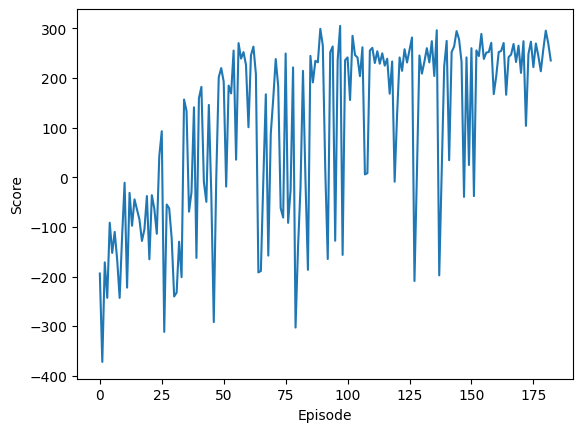

In [ ]:
episode = 0
start_time = time.perf_counter()
while (episode < NUMBER_OF_EPISODES_FOR_TRAINING):
    episode += 1
    score = 0
    state, info = environment.reset() # Set to a random initial state
    end_episode = False
    while not(end_episode):
        # Select an action for the current state using epsilon-greedy
        action = agent.select(state)

        # Execute the action on the environment
        state_next, reward, terminal_state, truncated, info = environment.step(action)

        # Store in memory the transition (s,a,r,s')
        agent.remember(state, action, reward, state_next, terminal_state)

        score += reward

        # Learn using a batch of experience stored in memory
        agent.learn()

        # Detect end of episode
        if terminal_state or truncated:
            agent.add_score(score)
            memoria = psutil.virtual_memory()
            print("Episode {0:>3}: ".format(episode), end = '')
            print("score {0:>3} ".format(math.trunc(score)), end = '')
            print("(exploration rate: %.2f, " % agent.exploration_rate, end = '')
            print("transitions: " + str(agent.memory.current_size) + ")", end = '')
            print(f" Memoria Utilizada: {memoria.used / (1024 * 1024 * 1024):.2f} GB")
            end_episode = True
        else:
            state = state_next

        time.sleep(0.01)

    """ Alternative stopping condition: if last n episodes give mean > 200

        if(len(agent.scores) >= STOPPING_STABLE_ITERS): # Stoping condition
            average_score = np.mean(agent.scores[max(0,(len(agent.scores)-STOPPING_STABLE_ITERS)):(len(agent.scores))])
            if(average_score >= SUCCESS_SCORE): # Score that is considered enough
                break
    """
    if(len(agent.scores) >= STOPPING_STABLE_ITERS): # Stoping condition: if all last n episodes are successes
        last_scores = agent.scores[max(0,(len(agent.scores)-STOPPING_STABLE_ITERS)):(len(agent.scores))]
        num_fails = sum(np.array(last_scores) < SUCCESS_SCORE)
        if(num_fails == 0):
            break

agent.model.save('red_1.h5')

print("Time for training:", round((time.perf_counter() - start_time)/60), "minutes")
print("Score (max):", max(agent.scores))
average_score = np.mean(agent.scores[max(0,(len(agent.scores)-STOPPING_STABLE_ITERS)):(len(agent.scores))])
print("Score (average last 20 episodes):", average_score)

agent.display_scores_graphically()

In [ ]:
show_video(folder_name)

Could not find video


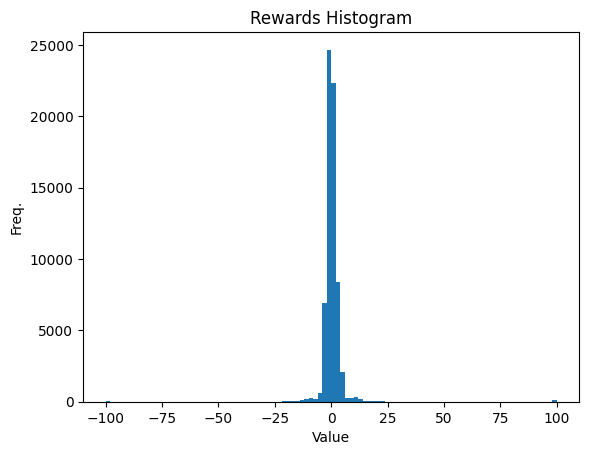

In [ ]:
import matplotlib.pyplot as plt

occupied_memory = agent.memory.current_size
rewards = agent.memory.rewards[0:occupied_memory] # Cut it up to occupied memory size

# Crear el histograma
plt.hist(rewards, bins=100)  # 'bins' is the number of intervals

plt.xlabel('Value')
plt.ylabel('Freq.')
plt.title('Rewards Histogram')

plt.show()

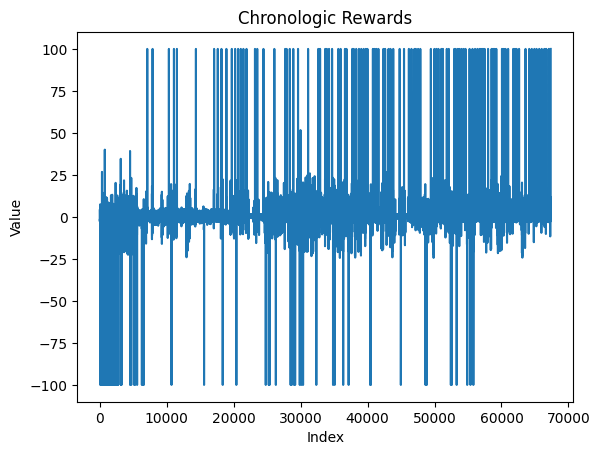

In [ ]:
indexes = np.arange(len(rewards))

plt.plot(indexes, rewards)

plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Chronologic Rewards')

plt.show()


## Testing program



In [25]:
#from google.colab import drive
#drive.mount('/content/drive')

agent.load_model()

In [26]:
agent.delete_scores()
episode = 0
start_time = time.perf_counter()
while (episode < NUMBER_OF_EPISODES_FOR_TESTING):
    episode += 1
    score = 0
    state, info = environment.reset()
    end_episode = False
    while not(end_episode):
        # Select an action for the current state (use greedy as the net is ready)
        action = agent.select_greedy_policy(state)

        # Execute the action in the environment
        state_next, reward, terminal_state, truncated, info = environment.step(action)

        score += reward

        # Detect end of episode and print
        if terminal_state or truncated:
            agent.add_score(score)
            print("Episode {0:>3}: ".format(episode), end = '')
            print("score {0:>3} \n".format(math.trunc(score)), end = '')
            end_episode = True
        else:
            state = state_next

        #estamos concienciados con la cpu, démosle un respiro
        time.sleep(0.01)

environment.close()

t:   0%|          | 2/415 [04:37<15:55:25, 138.80s/it, now=None]

Moviepy - Building video /content/video/01-18/rl-video-episode-0.mp4.
Moviepy - Writing video /content/video/01-18/rl-video-episode-0.mp4




t:   0%|          | 2/415 [04:39<16:01:53, 139.74s/it, now=None]

Moviepy - Done !
Moviepy - video ready /content/video/01-18/rl-video-episode-0.mp4
Episode   1: score 220 


t:   0%|          | 2/415 [05:35<19:15:35, 167.88s/it, now=None]

...

Moviepy - Done !
Moviepy - video ready /content/video/01-18/rl-video-episode-58.mp4
Episode  59: score 208 


t:   0%|          | 2/415 [51:23<176:53:19, 1541.89s/it, now=None]

Moviepy - Building video /content/video/01-18/rl-video-episode-59.mp4.
Moviepy - Writing video /content/video/01-18/rl-video-episode-59.mp4




t:   0%|          | 2/415 [51:25<176:59:27, 1542.78s/it, now=None]

Moviepy - Done !
Moviepy - video ready /content/video/01-18/rl-video-episode-59.mp4
Episode  60: score 195 


Time for testing: 48 minutes
Score average: 147.41059438692673
Score median: 205.27288435085615
Score standard deviation: 136.29181425608817
Number of successes 36
Score max: 267.38415075128466


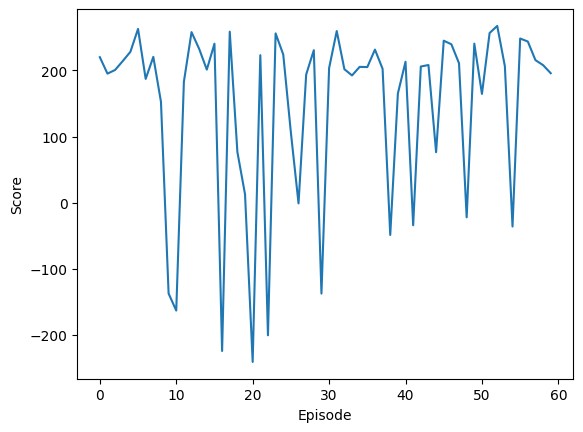

In [27]:
print("Time for testing:", round((time.perf_counter() - start_time)/60), "minutes")
print("Score average:", np.mean(agent.scores))
print("Score median:", np.median(agent.scores))
print("Score standard deviation:", np.std(agent.scores))
print("Number of successes", sum(np.array(agent.scores) >= SUCCESS_SCORE))
print("Score max:", max(agent.scores))

agent.display_scores_graphically()

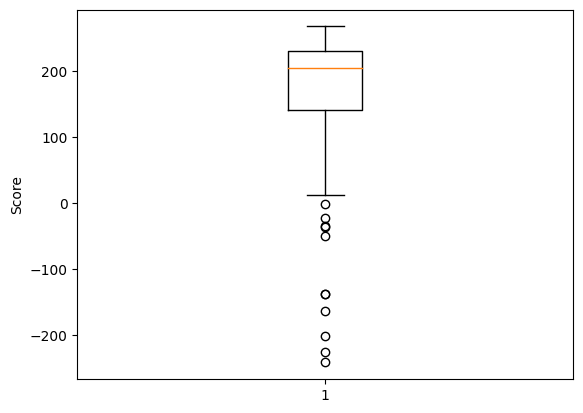

In [28]:
agent.display_boxplot()

In [32]:
best_run_index = np.argmax(agent.scores)
worst_run_index = np.argmin(agent.scores)

sorted_indices = np.argsort(agent.scores)
median_run_index = sorted_indices[len(sorted_indices) // 2]

# If the number of elements is even, we take the lower median (NumPy default)
if len(sorted_indices) % 2 == 0:
    median_run_index = sorted_indices[(len(sorted_indices) // 2) - 1]

Best run number 52 with score 267.38415075128466
Worst run number 20 with score -241.0092919956358
Median run number 35 with score 205.10371237271835


In [40]:
print(f'Best run number {best_run_index} with score {agent.scores[best_run_index]}')
show_video(folder_name, best_run_index)

Best run number 52 with score 267.38415075128466


In [41]:
print(f'Worst run number {worst_run_index} with score {agent.scores[worst_run_index]}')
show_video(folder_name, worst_run_index)

Worst run number 20 with score -241.0092919956358


In [42]:
print(f'Median run number {median_run_index} with score {agent.scores[median_run_index]}')
show_video(folder_name, median_run_index)

Median run number 35 with score 205.10371237271835


# Results, Conclusions, and Potential Improvements
- We have successfully trained the 3-layer model in 183 iterations thanks to the stopping condition.

- In the testing phase, we have a median score of 205 (above the successful threshold, 200), but the average drops to 147 due to some poor performances that result in negative scores. The successful runs account for 60% (36 out of 60).

- Videos show that in the best case there is a fast and smooth landing; in the worst case, there is an unlucky crash; and, in the median case it shows a robust behaviour against failing when having an initial bad start (probably because of the random initial force)

- Achieving a completely stable model is complex; there are always some runs that deviate from the norm. A possible improvement could be to ensure stability, perhaps by adding a second phase of the stopping condition after the one implemented, where there is no exploration so that it has the conditions of the test.

- The more complex scenario of this problem could be explored, which involves the use of wind, making the training more random but leading to more robust models.